IMPORTING LIBRARIES


In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATASET:

In [104]:
df = pd.read_csv("/content/campus_cafeteria_dataset.csv.csv")

UNDERSTANDING THE DATASET:

In [105]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           150 non-null    object
 1   Day            150 non-null    object
 2   Food_Item      150 non-null    object
 3   Category       150 non-null    object
 4   Meal_Time      150 non-null    object
 5   Price          150 non-null    int64 
 6   Weather        150 non-null    object
 7   Temperature_C  150 non-null    int64 
 8   Exam_Day       150 non-null    object
 9   Holiday        150 non-null    object
 10  Units_Sold     150 non-null    int64 
dtypes: int64(3), object(8)
memory usage: 13.0+ KB


,Price,Temperature_C,Units_Sold
count,150.000000,150.000000,150.000000
mean,61.200000,29.620000,43.193333
std,31.472157,3.746444,13.933060
min,20.000000,24.000000,10.000000
25%,30.000000,26.000000,33.250000
50%,50.000000,29.000000,43.000000
75%,90.000000,33.000000,52.000000
max,120.000000,36.000000,78.000000


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           150 non-null    object
 1   Day            150 non-null    object
 2   Food_Item      150 non-null    object
 3   Category       150 non-null    object
 4   Meal_Time      150 non-null    object
 5   Price          150 non-null    int64 
 6   Weather        150 non-null    object
 7   Temperature_C  150 non-null    int64 
 8   Exam_Day       150 non-null    object
 9   Holiday        150 non-null    object
 10  Units_Sold     150 non-null    int64 
dtypes: int64(3), object(8)
memory usage: 13.0+ KB


In [107]:
df.isnull().sum()

,0
Date,0
Day,0
Food_Item,0
Category,0
Meal_Time,0
Price,0
Weather,0
Temperature_C,0
Exam_Day,0
Holiday,0


In [108]:
df.duplicated().sum()

np.int64(0)

In [109]:
df.describe()


,Price,Temperature_C,Units_Sold
count,150.000000,150.000000,150.000000
mean,61.200000,29.620000,43.193333
std,31.472157,3.746444,13.933060
min,20.000000,24.000000,10.000000
25%,30.000000,26.000000,33.250000
50%,50.000000,29.000000,43.000000
75%,90.000000,33.000000,52.000000
max,120.000000,36.000000,78.000000


CHECKING THE UNIQUE VALUES FIRST:

In [110]:
print("Food Items:", df["Food_Item"].unique())
print("Weather:", df["Weather"].unique())
print("Meal Times:", df["Meal_Time"].unique())
print("Categories:", df["Category"].unique())

Food Items: ['Sandwich' 'Samosa' 'Puff' 'Noodles' 'Idli' 'Dosa' 'Fried Rice' 'Biryani']
Weather: ['Cloudy' 'Rainy' 'Sunny']
Meal Times: ['Evening' 'Lunch' 'Breakfast']
Categories: ['Snack' 'Main Course' 'Breakfast']


VISUALIZATION OF HIGHEST AVG SALES:

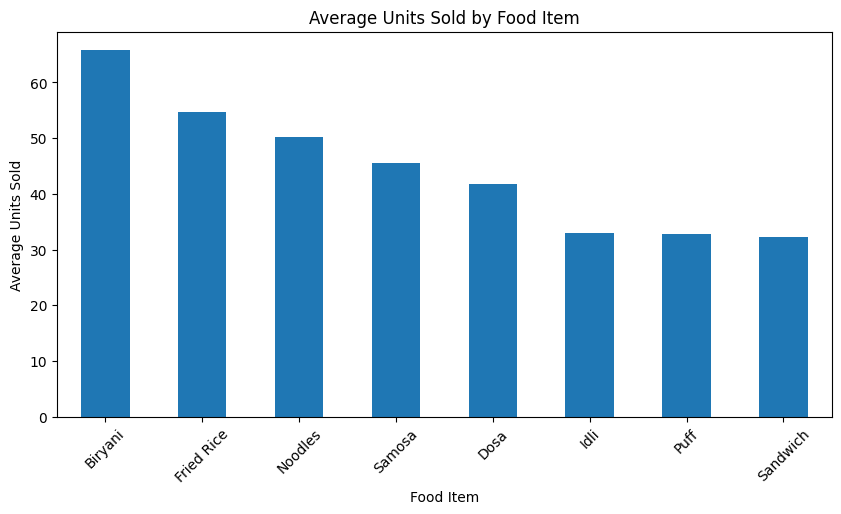

In [111]:
food_sales = df.groupby("Food_Item")["Units_Sold"].mean().sort_values(ascending=False)

food_sales.plot(kind="bar", figsize=(10,5))

plt.title("Average Units Sold by Food Item")
plt.xlabel("Food Item")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)
plt.show()

CREATING TARGET VARIABLE:

In [112]:
def classify_demand(units):
    if units < 35:
        return "Low"
    elif units <= 55:
        return "Medium"
    else:
        return "High"

df["Demand_Level"] = df["Units_Sold"].apply(classify_demand)

In [113]:
df["Demand_Level"].value_counts()

,count
Demand_Level,
Medium,80
Low,42
High,28


VISUALIZING THE TARGET VARIABLE:

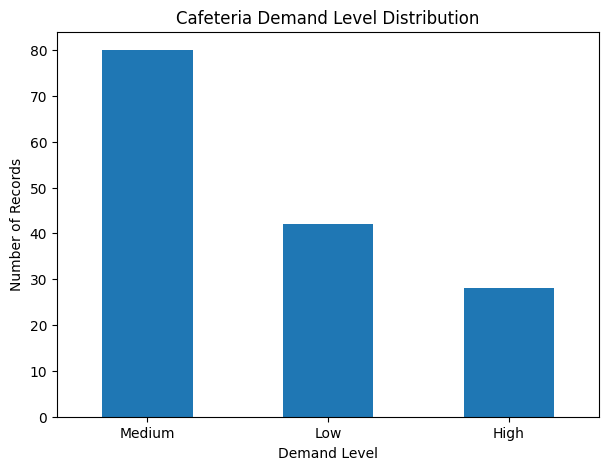

In [114]:
df["Demand_Level"].value_counts().plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Cafeteria Demand Level Distribution")
plt.xlabel("Demand Level")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

SEPARATING FEATURES AND TARGET X and y:

In [115]:
X = df.drop(columns=["Units_Sold", "Demand_Level", "Date"])
y = df["Demand_Level"]

IMPORTING LIBRARIES FOR ONE HOT ENCODER

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [117]:
categorical_columns = X.select_dtypes(include=["object"]).columns
numerical_columns = X.select_dtypes(include=["int64"]).columns

print("Categorical columns:", list(categorical_columns))
print("Numerical columns:", list(numerical_columns))

Categorical columns: ['Day', 'Food_Item', 'Category', 'Meal_Time', 'Weather', 'Exam_Day', 'Holiday']
Numerical columns: ['Price', 'Temperature_C']


TRAIN TEST SPLIT DATA: (80% TRAINING AND 20% TESTING)

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


ENCODE THE CATEGORICAL DATA:

In [119]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ("num", "passthrough", numerical_columns)
    ]
)

In [120]:
OneHotEncoder()

OneHotEncoder()

IMPORTING LIBRARIES FOR RANDOM FOREST MODEL:

In [121]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [122]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

TRAINING THE MODEL

In [123]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Day', 'Food_Item', 'Category', 'Meal_Time', 'Weather', 'Exam_Day',
       'Holiday'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['Price', 'Temperature_C'], dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=42))])

MAKE PREDICTIONS:

In [124]:
y_pred = model.predict(X_test)

EVALUATE THE MODEL:

In [125]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [126]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7333333333333333

Classification Report:
              precision    recall  f1-score   support

        High       0.80      0.67      0.73         6
         Low       0.71      0.62      0.67         8
      Medium       0.72      0.81      0.76        16

    accuracy                           0.73        30
   macro avg       0.75      0.70      0.72        30
weighted avg       0.74      0.73      0.73        30



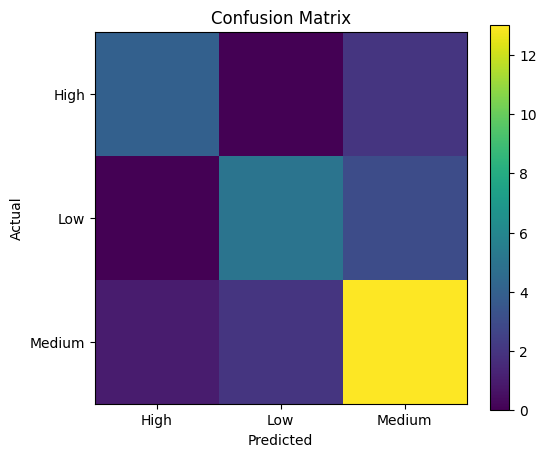

In [127]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    range(len(model.classes_)),
    model.classes_
)

plt.yticks(
    range(len(model.classes_)),
    model.classes_
)

plt.colorbar()
plt.show()

IMPORTING PY WIDGETS FOR INTERACTIVE DASHBOARD

In [128]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

CREATING INPUT CONTROLS FOR DASHBOARD:

In [129]:
# Input widgets

day_widget = widgets.Dropdown(
    options=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    description="Day:"
)

food_widget = widgets.Dropdown(
    options=["Samosa", "Sandwich", "Biryani", "Fried Rice",
             "Dosa", "Idli", "Puff", "Noodles"],
    description="Food:"
)

category_widget = widgets.Dropdown(
    options=["Snack", "Main Course", "Breakfast"],
    description="Category:"
)

meal_widget = widgets.Dropdown(
    options=["Breakfast", "Lunch", "Evening"],
    description="Meal:"
)

price_widget = widgets.IntSlider(
    value=60,
    min=20,
    max=120,
    step=10,
    description="Price:"
)

weather_widget = widgets.Dropdown(
    options=["Sunny", "Cloudy", "Rainy"],
    description="Weather:"
)

temperature_widget = widgets.IntSlider(
    value=30,
    min=24,
    max=36,
    step=1,
    description="Temp °C:"
)

exam_widget = widgets.Dropdown(
    options=["No", "Yes"],
    description="Exam Day:"
)

holiday_widget = widgets.Dropdown(
    options=["No", "Yes"],
    description="Holiday:"
)

CREATING PREDICT BUTTON AND RESULT AREA:

In [130]:
predict_button = widgets.Button(
    description="🔮 Predict Demand",
    button_style="primary",
    layout=widgets.Layout(width="220px", height="45px")
)

output = widgets.Output()

CREATING PREDICTION FUNCTION

In [131]:
def predict_demand(button):
    with output:
        clear_output()

        new_data = pd.DataFrame({
            "Day": [day_widget.value],
            "Food_Item": [food_widget.value],
            "Category": [category_widget.value],
            "Meal_Time": [meal_widget.value],
            "Price": [price_widget.value],
            "Weather": [weather_widget.value],
            "Temperature_C": [temperature_widget.value],
            "Exam_Day": [exam_widget.value],
            "Holiday": [holiday_widget.value]
        })

        prediction = model.predict(new_data)[0]

        if prediction == "High":
            icon = "🔥"
            message = "HIGH DEMAND"
            color = "#dc2626"
            background = "#fee2e2"

        elif prediction == "Medium":
            icon = "📊"
            message = "MEDIUM DEMAND"
            color = "#d97706"
            background = "#fef3c7"

        else:
            icon = "📉"
            message = "LOW DEMAND"
            color = "#16a34a"
            background = "#dcfce7"

        display(HTML(f"""
        <div style="
            margin-top:20px;
            padding:25px;
            border-radius:15px;
            background:{background};
            border:2px solid {color};
            text-align:center;
            max-width:500px;
        ">
            <h2 style="margin:0 0 10px 0;">
                Cafeteria Demand Prediction
            </h2>

            <p style="font-size:16px;">
                <b>{new_data['Food_Item'].iloc[0]}</b> |
                {new_data['Meal_Time'].iloc[0]} |
                {new_data['Weather'].iloc[0]}
            </p>

            <h1 style="color:{color}; margin:15px 0;">
                {icon} {message}
            </h1>

            <p style="margin:0;">
                Temperature: {new_data['Temperature_C'].iloc[0]}°C
                &nbsp; | &nbsp;
                Exam Day: {new_data['Exam_Day'].iloc[0]}
            </p>
        </div>
        """))

predict_button.on_click(predict_demand)

DISPLAYING THE INTERFACE

In [132]:
display(HTML("""
<h2>🍽️ Campus Cafeteria Demand Predictor</h2>
<p>Select the cafeteria conditions and click <b>Predict Demand</b>.</p>
"""))

display(
    widgets.VBox([
        day_widget,
        food_widget,
        category_widget,
        meal_widget,
        price_widget,
        weather_widget,
        temperature_widget,
        exam_widget,
        holiday_widget,
        predict_button,
        output
    ])
)